# Part 1: K'avi Tribe Water Quality

Link to the intro about K'avi tribe page 

## Part 1 Introduction 

when loading in data, use URL from the github repo 

in this file, we are comparing annual water quality metrics (dissolved oxygen, water temp.) at different sites over time 
in order to do this, we are going to clean a dataset and summarize by year, then plot it to visualize  
 we are primarily using these key packages through out workshop 
tidyverse, lubridate, janitor 

 There are two main variables we work with in this section: stream temperature and dissolved oxygen
 water temperature can be meaningful for protecting aquatic communities while maintaining socio-economic benefits (Ouellet-Proulx et al. 2017). Common water temperatures in lakes and streams range between 4 and 35 °C.
Dissolved oxygen (DO) is the concentration of oxygen dissolved in water. Common DO concentrations range between 0 and 12 mg L-1 and DO concentrations less than 2 mg L-1 are considered hypoxic

topics covered:
- cleaning data (removed unnecessary columns and rows with repeated header)
- filtering (example used was to take out the rows with text of col headers in them, not to extract desired values)
- summarizing by year
- ggplot - time series and boxplot 

In [6]:
#install necessary packages- packages increase the functionality of R/RStudio 
# if you already installed packages, do not need to do this again! 
#install.packages('janitor')

# load necessary libraries- libraries are the installed packages
library(tidyverse) # used for 'tidying' data: wrangling, analysis, visualizing 
library(lubridate) # used to handle data as dates 
#library(janitor)   # used to clean data sets

# make plots larger 
options(repr.plot.width = 12, repr.plot.height = 8)

Warning message:
"package 'janitor' is in use and will not be installed"


New names:
• `` -> `...1`
Rows: 561 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): sample_location, longitude, latitude
dbl  (7): ...1, DO, water_temp_C, water_temp_F, specific_conductivity, disch...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


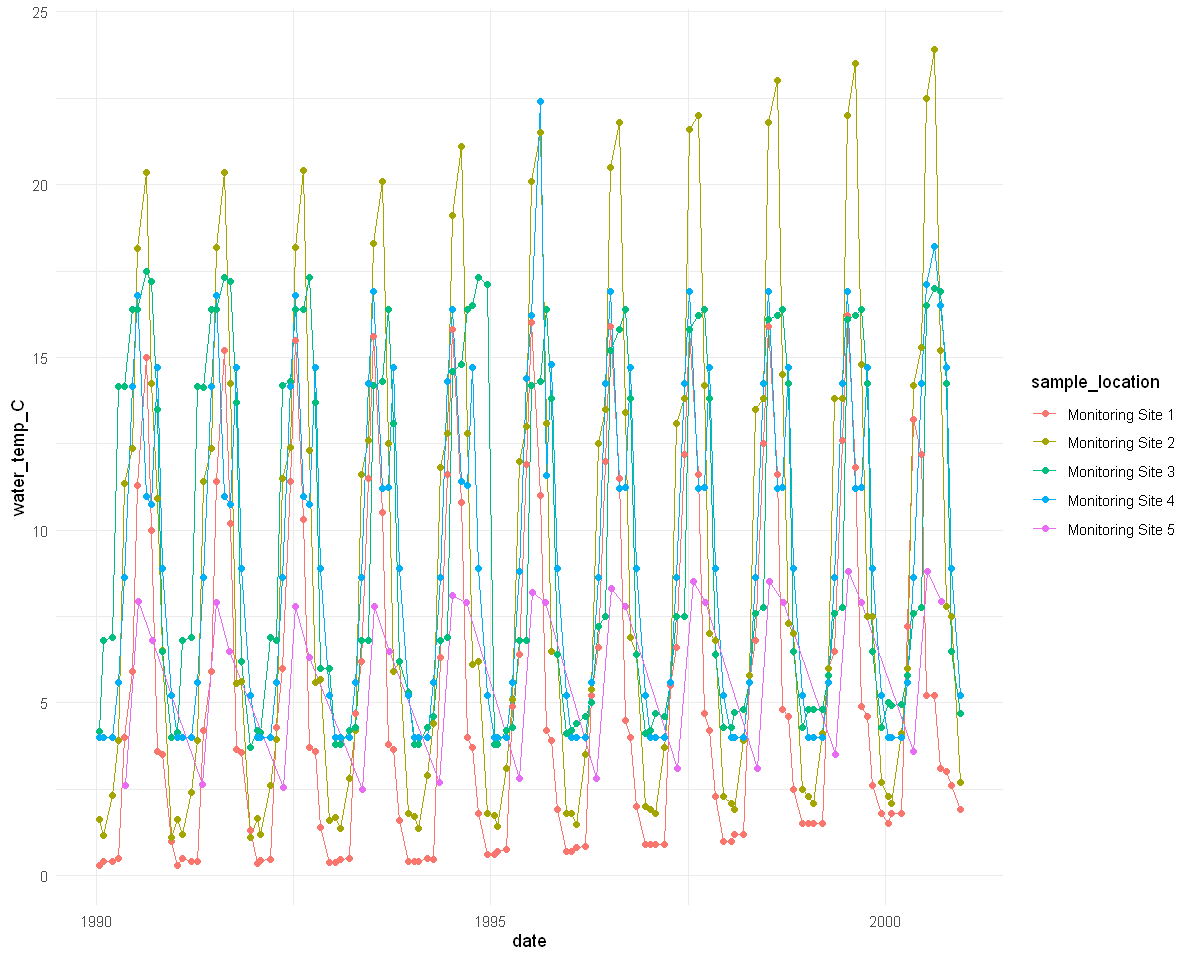

In [7]:
# increase the plot width
options(repr.plot.width=10, repr.plot.height=8)

# before we dive into the data cleaning part, load this data and let's see a plot 
water_example <- readr::read_csv("tidy_water_quality_dataset.csv")

# run this line for plot
# we will use the ggplot format, which follows:
## ggplot(dataset) + geom_plottype(aes(x, y))
water_example %>%
  ggplot(aes(x = date, y = water_temp_C, color = sample_location)) +
  geom_line() + geom_point() +
  theme_minimal()

## Workflow to create plot of water temperature 

In order to get to this point where we can explore visually, we first have to clean our original data set 

The process we will go through with our sample data set is to:
1. load from the CSV file and preview 
2. clean the data to make analysis and plotting easier 
3. explore data with summaries and visulizations
   
When we plot we can gain insight to bring in new data and repeat this process. 

Describe csv file more 

### Load and preview data 

We first use the `read.csv()` function and input the location of our file in quotations. 

Then we preview the data using `head()`, which outputs the first 6 rows in the data frame. 

In [8]:
# read in CSV file that we want to work with - should be located in your working director
water <- read.csv("K_avi_Tribe_Water_Quality_Dataset.csv")
# to see what the dataset looks like, use head() which outputs first 6 rows 
head(water)

,Sample.Location,Longitude,Latitude,Date,Dissolved.Oxygen.mg.L,Water.Temperature.0C,Water.Temperature.0.F,Specific.Conductance.umhos,Discharge.ft3.sec,X,X.1,X.2,X.3,X.4,X.5,X.6,X.7,X.8,X.9,X.10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,Monitoring Site 1,51.47.40 N,117.25.31 W,1/15/90,12.3,0.3,32.54,80,35,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,Monitoring Site 1,51.47.40 N,117.25.31 W,2/1/90,12.3,0.4,,82,27,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,Monitoring Site 1,51.47.40 N,117.25.31 W,3/15/90,12.3,0.4,,93,20,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Monitoring Site 1,51.47.40 N,117.25.31 W,4/12/90,11.9,0.5,,85,26,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Monitoring Site 1,51.47.40 N,117.25.31 W,5/11/90,11.8,4,,110,100,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,Monitoring Site 1,51.47.40 N,117.25.31 W,6/15/90,10.9,5.9,,180,261,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


#### Examine dataset 

`str()` is a function that gives us the structure of an object in R, here we use it to examine the structure of our dataset 

Note that it is displaying the type of data in each column:
- `chr` stands for character vector, or string - when printed, this type of data will have quotation marks
- `logi` is short for 'logical' which can contain True or False, but in our case NA

In [9]:
str(water)

'data.frame':	565 obs. of  20 variables:
 $ Sample.Location           : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ Longitude                 : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ Latitude                  : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ Date                      : chr  "1/15/90" "2/1/90" "3/15/90" "4/12/90" ...
 $ Dissolved.Oxygen.mg.L     : chr  "12.3" "12.3" "12.3" "11.9" ...
 $ Water.Temperature.0C      : chr  "0.3" "0.4" "0.4" "0.5" ...
 $ Water.Temperature.0.F     : chr  "32.54" "" "" "" ...
 $ Specific.Conductance.umhos: chr  "80" "82" "93" "85" ...
 $ Discharge.ft3.sec         : chr  "35" "27" "20" "26" ...
 $ X                         : logi  NA NA NA NA NA NA ...
 $ X.1                       : logi  NA NA NA NA NA NA ...
 $ X.2                       : logi  NA NA NA NA NA NA ...
 $ X.3                       : logi  NA NA NA NA NA NA ...
 $ X.4                     

**Questions** 

- How many rows and how many columns are there?
- What type of data are in each column? is that what you'd expect?
- Despite most of the columns containing what should just be numeric data all of the columns are filled with data that's a character. this suggests we should take a closer look at what is in each of these columns
- What are other problems that you're seeing with this dataset?

### Clean up data

In this section, we are cleaning up the data and making it easier to work with. 

We are working to make our dataset 'tidy' in that it follows:
- each variable is a column
- each observation is a row 
- each value is a single cell 

First we are going to select the columns we want (not including the empty NA columns) and rename the columns to easier names. 

Why change names? 
- it's easier to not have uppercase letters (R is case sensitive)
- we want it to be all one word with no spaces or periods 
- some words we might want to shorten i.e. temperature = 'temp'

Before selecting columns, let's make sure the extra ones don't contain any data. We can do this using `summary()` which outputs the statistics of each column if it contains numbers, and the length of the column if it contains characters or logical. It also shows how many NAs are in each column. In our example, the last 10 columns are only NA. 

In [10]:
summary(water)

 Sample.Location     Longitude           Latitude             Date          
 Length:565         Length:565         Length:565         Length:565        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
 Dissolved.Oxygen.mg.L Water.Temperature.0C Water.Temperature.0.F
 Length:565            Length:565           Length:565           
 Class :character      Class :character     Class :character     
 Mode  :character      Mode  :character     Mode  :character     
 Specific.Conductance.umhos Discharge.ft3.sec     X             X.1         
 Length:565                 Length:565         Mode:logical   Mode:logical  
 Class :character           Class :character   NA's:565       NA's:565      
 Mode  :character           Mode  :character                                
   X.2            X.3            X.4            X.5            X.6         
 Mode:logical   Mode:logical   Mode:logical 

Let's remove those columns. To do this we are using `select()` from tidyverse package - this allows us to select the columns we want and rename them in the process. 

Below we use a pipe (which can look like `%>%` or `|>`), which takes the name of a data frame that comes before it and applies the function that comes after it. 

In [11]:
water_tidy <- water %>%
  select(sample_location = "Sample.Location",
         longitude = "Longitude",
         latitude = "Latitude",
         date = "Date",
         DO = "Dissolved.Oxygen.mg.L",
         water_temp_C = "Water.Temperature.0C",
         water_temp_F = "Water.Temperature.0.F",
         specific_conductivity = "Specific.Conductance.umhos",
         discharge = "Discharge.ft3.sec")

💻**Your turn!** Check how the new data frame, `water_tidy` has changed from the original using `head()` or `str()` from above

In [12]:
# add your code here 

You may have noticed when we ran `summary()` there were some variables listed as characters that we might expect to be numeric. Sometimes this happens if there is a row that contains character data mixed in with the numeric data.

we need our columns to be numeric so we can run analysis and make plots - you get an error if they are saved as characters. 

We will check for and identify any duplicates here using the function `distinct()` from tidyverse and `get_dupes()` from the janitor package.


In [13]:
# count the unique number of row combinations 
n_distinct(water_tidy)

# see output of duplicated rows 
get_dupes(water_tidy)

[1] 563

No variable names specified - using all columns.




sample_location,longitude,latitude,date,DO,water_temp_C,water_temp_F,specific_conductivity,discharge,dupe_count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
Sample Location,Longitude,Latitude,Date,Dissolved Oxygen mg/L,Water Temperature 0C,Water Temperature 0 F,Specific Conductance umhos,Discharge ft3/sec,3
Sample Location,Longitude,Latitude,Date,Dissolved Oxygen mg/L,Water Temperature 0C,Water Temperature 0 F,Specific Conductance umhos,Discharge ft3/sec,3
Sample Location,Longitude,Latitude,Date,Dissolved Oxygen mg/L,Water Temperature 0C,Water Temperature 0 F,Specific Conductance umhos,Discharge ft3/sec,3


It looks like our data frame contains duplicate rows of column names. Let's remmove those using `filter()` from tidyverse. 
The filter function takes a criteria for a column and checks whether it is true or not. Here, `!=` means it is not equal to. 

In [14]:
# to remove these rows, we use filter() from tidyverse  
# filter function takes a criteria for a column and checks whether it is true or not, here "!=" means it is not equal to 
water_filt <- water_tidy %>%
  filter(sample_location != "Sample Location") 

# preview new data frame with summary 
summary(water_filt)

 sample_location     longitude           latitude             date          
 Length:561         Length:561         Length:561         Length:561        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
      DO            water_temp_C       water_temp_F       specific_conductivity
 Length:561         Length:561         Length:561         Length:561           
 Class :character   Class :character   Class :character   Class :character     
 Mode  :character   Mode  :character   Mode  :character   Mode  :character     
  discharge        
 Length:561        
 Class :character  
 Mode  :character  

Next we need to change some of our columns from character data types to numeric. 

Even though we removed the col names with characters, `DO`, `water_temp_C`, `water_temp_F`, `specific_conductivity`, and `discharge` are all columns that need to be numeric values. We can do this using tidyverse function `mutate()`. 

In [21]:
water_num <- water_filt %>% mutate(
  DO = as.numeric(DO),
  water_temp_C = as.numeric(water_temp_C)
)

💻**Your turn!**: Can you use `mutate()` to change the other variables (water_temp_F, specific_conductivity, discharge) to numeric? Save it as the same dataframe, `water_num`

In [ ]:
# enter your code here

### Working with dates

Dates in R are saved as a data format, different from a numerica data type. We can use the `lubridate` package  to change our date column into date format of month, day, year, `mdy()`. Learn more about lubridate [here](https://lubridate.tidyverse.org/).

In addition to using `mutate()` to create or edit a column, we can use the format of calling a vector with `$` to edit. In this example, we update the `date` column. 

💻**Your turn!**: In the next code chunk, add a line to run `summary()` again and see what happened to the `date` column.

In [22]:
# update date column 
water_num$date <- mdy(water_num$date) 

# see update to date 


For future analysis we'll need to group data by year, so let's make one more column that is the year the sample was collected because our date column is the type `Date`, we can use the `year` function from `lubridate` to extract the year and make it another column.  

We can also preview the data types in our data frame again using `str()`

In [23]:
# create year column 
water_num$year <- year(water_num$date) 

str(water_num)

'data.frame':	561 obs. of  10 variables:
 $ sample_location      : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ longitude            : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ latitude             : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ date                 : Date, format: "1990-01-15" "1990-02-01" ...
 $ DO                   : num  12.3 12.3 12.3 11.9 11.8 10.9 9 7.8 8.5 11.8 ...
 $ water_temp_C         : num  0.3 0.4 0.4 0.5 4 5.9 11.3 15 10 3.6 ...
 $ water_temp_F         : num  32.5 NA NA NA NA ...
 $ specific_conductivity: num  80 82 93 85 110 180 153 89 78 80 ...
 $ discharge            : num  35 27 20 26 100 261 195 48 22 36 ...
 $ year                 : num  1990 1990 1990 1990 1990 1990 1990 1990 1990 1990 ...


Last step to cleaning our data is to save it as a new file!

To do this, use `write.csv()`, where the first input is the name of the data frame in R and the second input is the file name. 

In [24]:
write.csv(water_num, file="K-avi_tribe_water_quality_dataset_clean.csv")

## Visualizing and Summarizing data 

We can use plotting to explore our data, and look for any patterns or outliers. 

`ggplot` can be used to do many different types of plots, and there are some examples below. The general format is: 

`ggplot(data=dataframe, aes(x,y)) + geom_plottype()` 

where plottype can be line, point, boxplot, etc. See more information at this [ggplot cheatsheet](https://www.maths.usyd.edu.au/u/UG/SM/STAT3022/r/current/Misc/data-visualization-2.1.pdf)

Let's start with a time series below. 

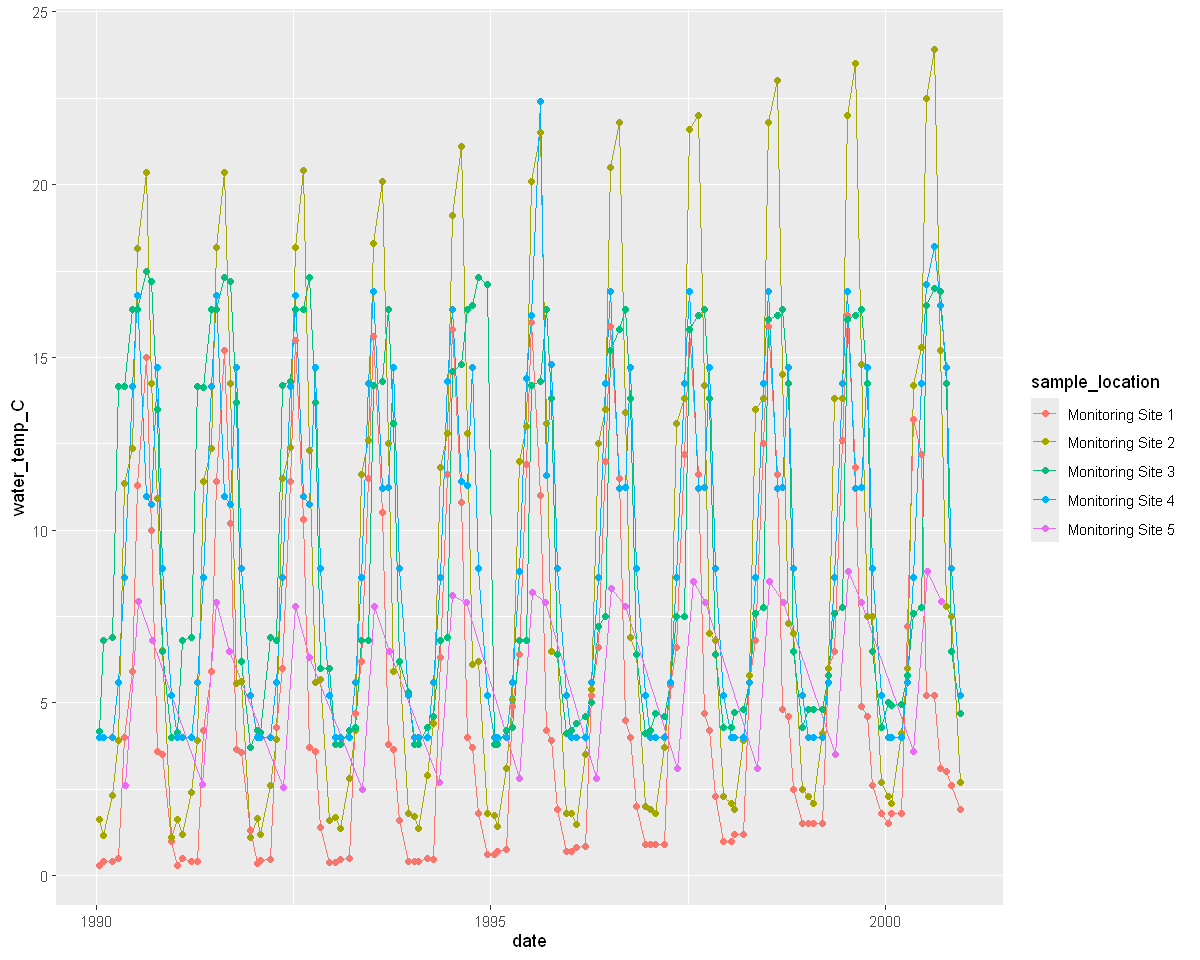

In [25]:
water_num %>%
  ggplot(aes(x = date, y = water_temp_C, color = sample_location)) +
  geom_line() + geom_point() 

When exploring data, it's good to look at distribution of a single variable. We can do this with boxplots, histograms, density plots - starting with `water_temp_C`. 

💻**Your turn!**: using this formula: `ggplot(water_num, aes(x=water_temp_C))` add different `geoms` to plot the distribution (`geom_boxplot()`, `geom_density()`, `geom_histogram()`)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


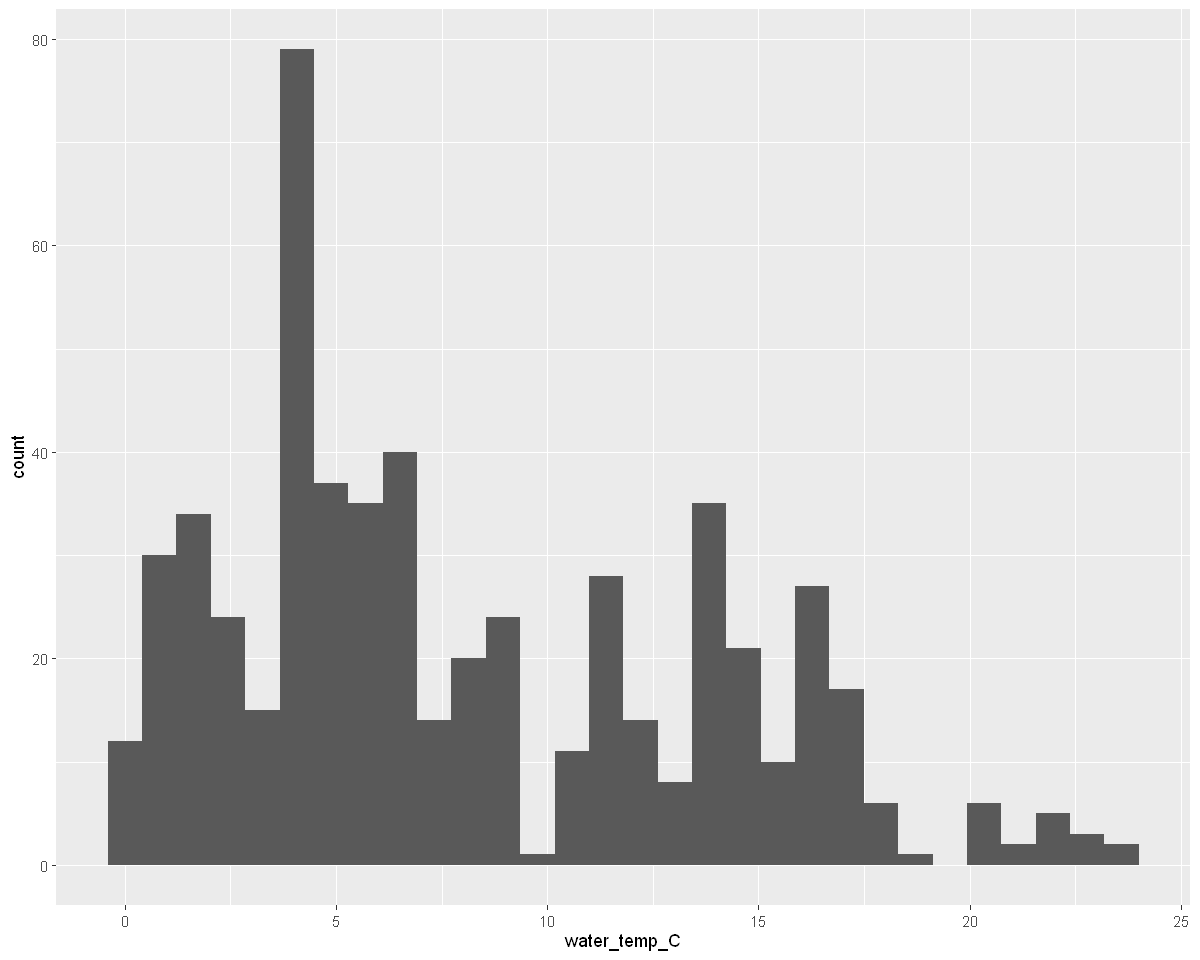

In [36]:
# your turn 

These can also be separated into groups based on sample location. 

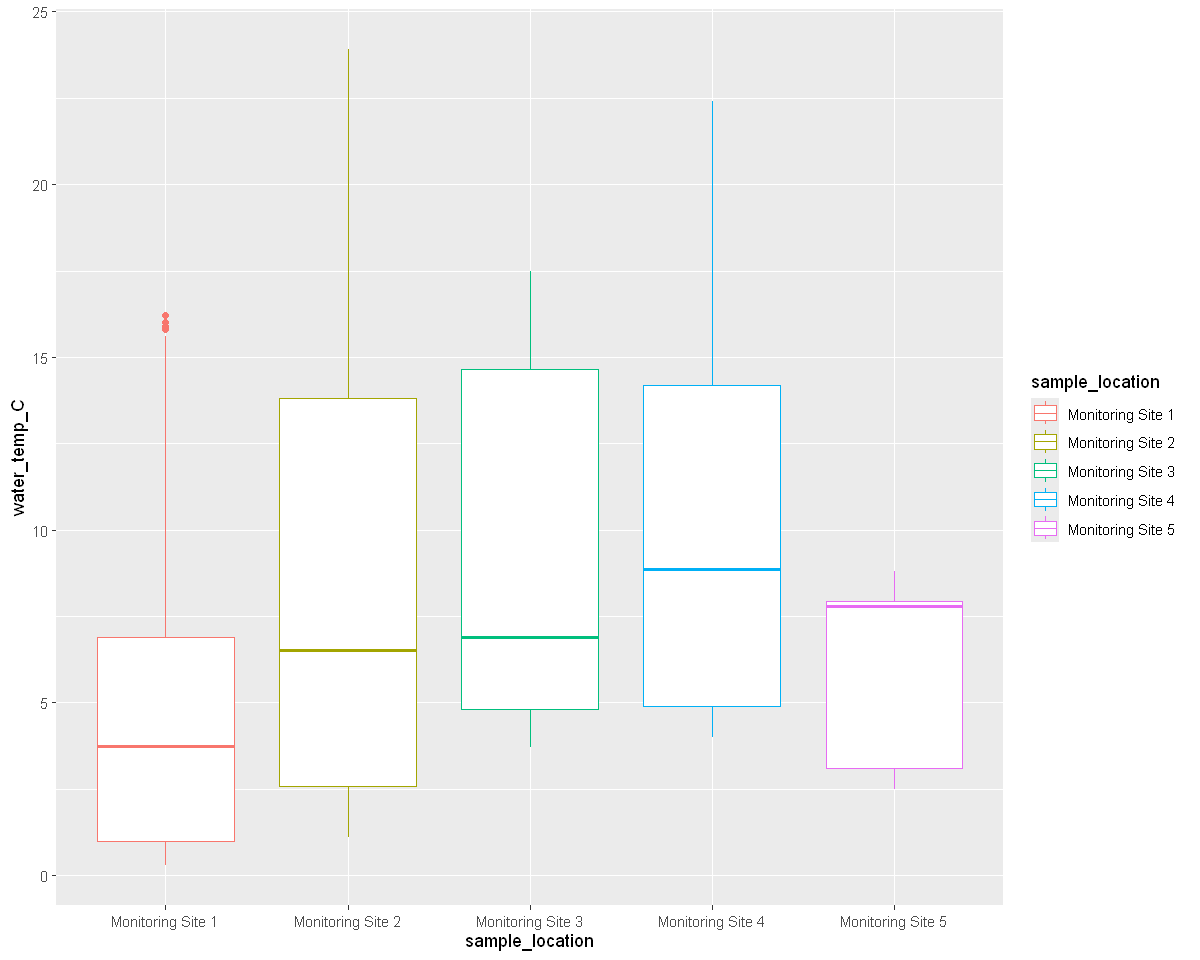

In [38]:
# plot boxplot by sample location 
ggplot(water_num, aes(x=sample_location, y=water_temp_C, col=sample_location)) + geom_boxplot()

### Summarize to annual values 

We want to visualize annual values, to do this we need to summarize our data and store it as a new dataset. We do this using the functions `group_by()` and `summarize()`.  

In [41]:
# create a dataframe of the summary statistics
water_ann_mean <- water_num %>%
  # group the data first by sampling location and then year
 group_by(sample_location, year) %>%
  # summarize the data
  # summarize() along with across() can be used to apply a function to multiple columns, in our case we use mean, but could change or add to this 
  summarize(across(c(DO, water_temp_C, specific_conductivity, discharge), list(mean=mean))) 

# preview new data frame - how has the structure changed? 
str(water_ann_mean)

`summarise()` has grouped output by 'sample_location'. You can override using the `.groups` argument.


gropd_df [55 × 6] (S3: grouped_df/tbl_df/tbl/data.frame)
 $ sample_location           : chr [1:55] "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ year                      : num [1:55] 1990 1991 1992 1993 1994 ...
 $ DO_mean                   : num [1:55] 11 11 10.9 10.7 10.5 ...
 $ water_temp_C_mean         : num [1:55] 4.66 4.75 4.82 4.94 4.7 ...
 $ specific_conductivity_mean: num [1:55] 100 99 101 104 104 ...
 $ discharge_mean            : num [1:55] 74.2 73.7 74.9 70.8 75.9 ...
 - attr(*, "groups")= tibble [5 × 2] (S3: tbl_df/tbl/data.frame)
  ..$ sample_location: chr [1:5] "Monitoring Site 1" "Monitoring Site 2" "Monitoring Site 3" "Monitoring Site 4" ...
  ..$ .rows          : list<int> [1:5] 
  .. ..$ : int [1:11] 1 2 3 4 5 6 7 8 9 10 ...
  .. ..$ : int [1:11] 12 13 14 15 16 17 18 19 20 21 ...
  .. ..$ : int [1:11] 23 24 25 26 27 28 29 30 31 32 ...
  .. ..$ : int [1:11] 34 35 36 37 38 39 40 41 42 43 ...
  .. ..$ : int [1:11] 45 46 47 48 49

💻**Your turn!**: Create a time series plot of `water_ann_mean` with `year` on the x-axis and `water_temp_C_mean` on the y axis, colored by `sample_location`

In [44]:
# time series plot here. (hint: start with ggplot(water_ann_mean))


Do a reasoning check - based on photo of the monitoring sites, why do you think monitoring sites 1 and 5 are colder? (temp. unit conversion 5C ~ 41F; 10C ~ 50F)

Plot another variable by year here. 

In [ ]:
# create another time series with variable other than temperature 

## Part 1 Recap

topics covered:
- cleaning data (removed unnecessary columns and rows with repeated header)
- filtering, selecting, mutating 
- grouping and summarizing by year
- ggplot - time series, boxplot, and distribution  